<a href="https://colab.research.google.com/github/pedrosolonassis/01_dados_fabrica/blob/main/NotebookClassifica%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Os datasets são:
#### Ao escolher o dataset que você vai trabalhar, copie o path e cole na célula de abetura do arquivo para ter acesso ao dataframe.

*   **Banknote Authentication** — Features extraídas de imagens de notas de dinheiro (variância, assimetria, curtose e entropia da imagem), prevendo se a nota é falsa ou verdadeira.
https://www.kaggle.com/datasets/ritesaluja/bank-note-authentication-uci-data

*   **Credit Card Fraud Detection** — Dataset de transações de cartão de crédito, onde as features já vêm como componentes numéricos (resultado de uma transformação PCA aplicada previamente pelos criadores do dataset, por questão de privacidade dos dados bancários reais) — ou seja, todas as colunas já são numéricas por padrão, sem nenhuma categórica pra converter.
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas de Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report,
                            roc_auc_score, roc_curve)

# Configurar estilo para melhores visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Todas as bibliotecas importadas com sucesso!")
print("Versão do Scikit-learn:", sklearn.__version__)


Todas as bibliotecas importadas com sucesso!
Versão do Scikit-learn: 1.6.1


In [4]:
# Carregue seu dataset aqui
# Coloque o caminho do arquivo CSV que você baixou do Kaggle entre as aspas abaixo
df = pd.read_csv('/BankNote_Authentication.csv')  # TODO: coloque o path do seu arquivo CSV aqui

df.head(10)

# Separe suas features (X) e seu target (y)
# X = todas as colunas que serão usadas para classificar (menos a coluna target)
# y = a coluna que você quer prever (precisa ter só 2 classes, representadas como 0 e 1)

X = df.drop(columns=[''])  # TODO: coloque o nome da(s) coluna(s) que NÃO serão usadas como feature (ex: 'diagnosis')
y = df['']  # TODO: coloque o nome da coluna que será o seu target (ex: 'diagnosis')

# TODO: defina o nome de cada classe, na ordem que elas aparecem como 0 e 1 no seu target
# ex: class_names = ["Não Sobreviveu", "Sobreviveu"]
class_names = ['', '']

print("Dataset carregado com sucesso!")
print(f"Formato do dataset: {X.shape}")
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de features: {X.shape[1]}")
print(f"Classes do target: {class_names}")
print(f"Distribuição das classes:")
print(f"  {class_names[0]} (0): {sum(y == 0)} casos ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"  {class_names[1]} (1): {sum(y == 1)} casos ({sum(y == 1)/len(y)*100:.1f}%)")

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.80730,-0.44699,0
1,4.54590,8.1674,-2.45860,-1.46210,0
2,3.86600,-2.6383,1.92420,0.10645,0
3,3.45660,9.5228,-4.01120,-3.59440,0
4,0.32924,-4.4552,4.57180,-0.98880,0
5,4.36840,9.6718,-3.96060,-3.16250,0
6,3.59120,3.0129,0.72888,0.56421,0
7,2.09220,-6.8100,8.46360,-0.60216,0
8,3.20320,5.7588,-0.75345,-0.61251,0
9,1.53560,9.1772,-2.27180,-0.73535,0


In [ ]:
# Exibir informações básicas sobre nosso dataset
print("=== VISÃO GERAL DO DATASET ===")
print(f"Formato do dataset: {X.shape}")
print(f"Formato do target: {y.shape}")
print("\n=== PRIMEIRAS 5 LINHAS ===")
print(X.head())

print("\n=== RESUMO ESTATÍSTICO ===")
print(X.describe())

print("\n=== TIPOS DE DADOS E VALORES AUSENTES ===")
print(X.info())
print(f"\nValores ausentes nas features: {X.isnull().sum().sum()}")
print(f"Valores ausentes no target: {pd.isnull(y).sum()}")

print("\n=== INFORMAÇÕES SOBRE O TARGET ===")
print(f"Valores únicos: {np.unique(y)}")
print(f"Contagem por classe:")
unique, counts = np.unique(y, return_counts=True)
for class_val, count in zip(unique, counts):
    class_name = class_names[class_val]
    print(f"  {class_name} ({class_val}): {count} casos")


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
class_counts = pd.Series(y).value_counts().sort_index()
plt.bar(class_names, class_counts.values, alpha=0.7, color=['lightcoral', 'lightblue'])
plt.title('Distribuição das Classes')
plt.ylabel('Número de Casos')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_names, autopct='%1.1f%%',
        colors=['lightcoral', 'lightblue'], startangle=90)
plt.title('Proporção das Classes')

plt.tight_layout()
plt.show()

print(f"Estatísticas das classes:")
for i, name in enumerate(class_names):
    count = sum(y == i)
    percentage = count / len(y) * 100
    print(f"{name}: {count} casos ({percentage:.1f}%)")

ratio = max(class_counts) / min(class_counts)
print(f"\nRazão de desbalanceamento: {ratio:.2f}")
if ratio > 2:
    print("⚠️  Dataset apresenta desbalanceamento significativo")
else:
    print("✓ Dataset relativamente balanceado")

In [ ]:
print("=== FEATURES (X) ===")
print(f"Formato das features: {X.shape}")
print(f"Nomes das features (primeiras 10): {list(X.columns[:10])}")
print(f"Tipos das features: {X.dtypes.unique()}")

print("\n=== TARGET (y) ===")
print(f"Formato do target: {y.shape}")
print(f"Tipo do target: {type(y)}")
print(f"Valores únicos do target: {np.unique(y)}")
print(f"Target representa: {class_names}")

# Vamos analisar as 6 primeiras features para visualizar diferenças entre classes
main_features = list(X.columns[:6])
print(f"\n=== ANÁLISE DAS PRINCIPAIS FEATURES ===")
print(f"Analisando {len(main_features)} features principais")

plt.figure(figsize=(15, 10))
for i, feature in enumerate(main_features):
    plt.subplot(2, 3, i+1)

    classe_0_data = X[y == 0][feature]
    classe_1_data = X[y == 1][feature]

    plt.hist(classe_0_data, alpha=0.7, label=class_names[0], bins=20, color='lightcoral')
    plt.hist(classe_1_data, alpha=0.7, label=class_names[1], bins=20, color='lightblue')

    plt.xlabel(feature)
    plt.ylabel('Frequência')
    plt.title(f'Distribuição de {feature}')
    plt.legend()

plt.tight_layout()
plt.show()

print("✓ Visualizações mostram diferentes distribuições entre classes")
print("✓ Isso indica que essas features podem ser úteis para classificação")

In [ ]:
# Criar DataFrame completo com features e target para análise de correlação
df_complete = X.copy()
df_complete['target'] = y

# Calcular matriz de correlação
correlation_matrix = df_complete.corr()

print("=== ANÁLISE DE CORRELAÇÃO ===")
print(f"Matriz de correlação calculada: {correlation_matrix.shape}")

# Visualizar matriz de correlação completa (será grande, então vamos criar um heatmap resumido)
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação Completa das Features')
plt.tight_layout()
plt.show()

# Analisar correlação das features com o target
target_correlation = correlation_matrix['target'].drop('target').sort_values(key=abs, ascending=False)

print(f"\n=== TOP 10 FEATURES MAIS CORRELACIONADAS COM O TARGET ===")
for i, (feature, corr) in enumerate(target_correlation.head(10).items()):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"{i+1:2d}. {feature:<35} | Correlação: {corr:6.3f} ({direction})")

print(f"\n=== INTERPRETAÇÃO DAS CORRELAÇÕES COM TARGET ===")
print(f"Correlação positiva: feature maior → maior probabilidade de ser {class_names[1]}")
print(f"Correlação negativa: feature maior → maior probabilidade de ser {class_names[0]}")

# Identificar features altamente correlacionadas entre si (multicolinearidade)
print(f"\n=== ANÁLISE DE MULTICOLINEARIDADE ===")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9 and correlation_matrix.columns[i] != 'target' and correlation_matrix.columns[j] != 'target':
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

if high_corr_pairs:
    print(f"Pares de features com correlação muito alta (>0.9):")
    for feature1, feature2, corr in high_corr_pairs[:10]:  # Mostrar apenas os primeiros 10
        print(f"  {feature1} <-> {feature2}: {corr:.3f}")
    print("⚠️  Alta correlação entre features pode indicar redundância")
else:
    print("✓ Não há features com correlação extremamente alta")

print(f"\nTotal de pares com correlação > 0.9: {len(high_corr_pairs)}")


In [ ]:
# Dividir os dados em conjuntos de treino e teste
# test_size=0.2 significa 20% para teste, 80% para treino
# random_state=42 garante resultados reproduzíveis (mesma divisão sempre)
# stratify=y mantém a proporção das classes em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Importante para classificação!
)

print("=== RESULTADOS DA DIVISÃO DOS DADOS ===")
print(f"Tamanho do dataset original: {X.shape[0]} amostras")
print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print(f"\nFormato das features de treino: {X_train.shape}")
print(f"Formato do target de treino: {y_train.shape}")
print(f"Formato das features de teste: {X_test.shape}")
print(f"Formato do target de teste: {y_test.shape}")

# Verificar se a estratificação funcionou (proporção das classes mantida)
print(f"\n=== VERIFICAÇÃO DA ESTRATIFICAÇÃO ===")
print("Distribuição das classes no dataset original:")
for i, name in enumerate(class_names):
    count_orig = sum(y == i)
    pct_orig = count_orig / len(y) * 100
    print(f"  {name}: {count_orig} casos ({pct_orig:.1f}%)")

print("\nDistribuição das classes no conjunto de treino:")
for i, name in enumerate(class_names):
    count_train = sum(y_train == i)
    pct_train = count_train / len(y_train) * 100
    print(f"  {name}: {count_train} casos ({pct_train:.1f}%)")

print("\nDistribuição das classes no conjunto de teste:")
for i, name in enumerate(class_names):
    count_test = sum(y_test == i)
    pct_test = count_test / len(y_test) * 100
    print(f"  {name}: {count_test} casos ({pct_test:.1f}%)")

print("✓ Estratificação manteve a proporção das classes em ambos os conjuntos!")

In [ ]:
# Antes do escalonamento - vamos ver as distribuições originais das features
print("=== ANTES DO ESCALONAMENTO ===")
print("Estatísticas das features do conjunto de treino (primeiras 5):")
print(X_train.iloc[:, :5].describe())

# Criar uma instância do StandardScaler
scaler = StandardScaler()

# IMPORTANTE: Ajustar o scaler APENAS nos dados de treino
# Isso previne vazamento de dados do conjunto de teste
scaler.fit(X_train)

# Transformar ambos os conjuntos (treino e teste) usando o scaler ajustado
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para manipulação mais fácil (opcional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n=== APÓS O ESCALONAMENTO ===")
print("Estatísticas das features escalonadas do conjunto de treino (primeiras 5):")
print(X_train_scaled.iloc[:, :5].describe())

print(f"\n✓ Todas as features agora têm média ≈ 0 e desvio ≈ 1")
print(f"✓ Scaler foi ajustado apenas nos dados de treino")
print(f"✓ Mesma transformação aplicada em ambos os conjuntos (treino e teste)")

# Visualizar o efeito do escalonamento em algumas features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
main_features = [col for col in X.columns if 'mean' in col][:6]

for i, feature in enumerate(main_features):
    row, col = i // 3, i % 3

    # Antes do escalonamento
    axes[row, col].hist(X_train[feature], alpha=0.7, label='Antes', bins=20)
    # Depois do escalonamento
    axes[row, col].hist(X_train_scaled[feature], alpha=0.7, label='Depois', bins=20)

    axes[row, col].set_title(f'{feature}')
    axes[row, col].legend()
    axes[row, col].set_ylabel('Frequência')

plt.tight_layout()
plt.suptitle('Comparação: Antes vs Depois do Escalonamento', y=1.02)
plt.show()

print("✓ Visualização mostra como o escalonamento centraliza e padroniza as distribuições")


In [ ]:
# Criar um modelo de Regressão Logística
model = LogisticRegression(random_state=42, max_iter=1000)

print("=== TREINAMENTO DO MODELO ===")
print(f"Modelo criado: {model}")
print(f"Treinando com {X_train_scaled.shape[0]} amostras e {X_train_scaled.shape[1]} features")

# Treinar o modelo com nossos dados de treino escalonados
# É aqui que o modelo aprende a relação entre features e classes
model.fit(X_train_scaled, y_train)

print("✓ Treinamento do modelo concluído!")

# Vamos examinar o que o modelo aprendeu
print(f"\n=== PARÂMETROS DO MODELO ===")
print(f"Intercepto (β₀): {model.intercept_[0]:.4f}")
print(f"Número de coeficientes: {len(model.coef_[0])}")

# Exibir os coeficientes mais importantes (em valor absoluto)
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_[0]
})
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print(f"\n=== TOP 10 FEATURES MAIS IMPORTANTES (por valor absoluto do coeficiente) ===")
for i, row in feature_importance.head(10).iterrows():
    coef = row['Coefficient']
    direction = "aumenta" if coef > 0 else "diminui"
    print(f"{row.name+1:2d}. {row['Feature']:<35} | Coef: {coef:7.4f} | {direction} prob. benigno")

print(f"\n=== INTERPRETAÇÃO DOS COEFICIENTES ===")
print(f"Coeficiente positivo: feature maior → maior probabilidade de ser {class_names[1].upper()}")
print(f"Coeficiente negativo: feature maior → maior probabilidade de ser {class_names[0].upper()}")


In [ ]:
# Fazer predições nos conjuntos de treino e teste

# Predições de classe (0 ou 1)
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Predições de probabilidade (valores entre 0 e 1)
y_train_proba = model.predict_proba(X_train_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

print("=== PREDIÇÕES REALIZADAS ===")
print(f"Formato das predições de treino: {y_train_pred.shape}")
print(f"Formato das predições de teste: {y_test_pred.shape}")
print(f"Formato das probabilidades de treino: {y_train_proba.shape}")
print(f"Formato das probabilidades de teste: {y_test_proba.shape}")

# Vamos examinar alguns exemplos de predições vs valores reais
print(f"\n=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===")
comparison_df = pd.DataFrame({
    'Real': y_test[:10],
    'Predito': y_test_pred[:10],
    f'Prob_{class_names[0]}': y_test_proba[:10, 0],
    f'Prob_{class_names[1]}': y_test_proba[:10, 1],
    'Confiança': np.max(y_test_proba[:10], axis=1)
})

# Adicionar nome das classes para melhor interpretação
comparison_df['Real_Nome'] = comparison_df['Real'].map({0: class_names[0], 1: class_names[1]})
comparison_df['Predito_Nome'] = comparison_df['Predito'].map({0: class_names[0], 1: class_names[1]})
comparison_df['Correto'] = comparison_df['Real'] == comparison_df['Predito']

print(comparison_df[['Real_Nome', 'Predito_Nome', f'Prob_{class_names[0]}', f'Prob_{class_names[1]}', 'Confiança', 'Correto']])

print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
print(f"Conjunto de treino:")
print(f"  Predições classe 0 ({class_names[0]}): {sum(y_train_pred == 0)}")
print(f"  Predições classe 1 ({class_names[1]}): {sum(y_train_pred == 1)}")
print(f"Conjunto de teste:")
print(f"  Predições classe 0 ({class_names[0]}): {sum(y_test_pred == 0)}")
print(f"  Predições classe 1 ({class_names[1]}): {sum(y_test_pred == 1)}")

# Analisar distribuição de confiança
confidence_test = np.max(y_test_proba, axis=1)
print(f"\n=== ANÁLISE DE CONFIANÇA ===")
print(f"Confiança média: {confidence_test.mean():.3f}")
print(f"Confiança mínima: {confidence_test.min():.3f}")
print(f"Confiança máxima: {confidence_test.max():.3f}")
print(f"Predições com alta confiança (>0.9): {sum(confidence_test > 0.9)} de {len(confidence_test)}")

=== PREDIÇÕES REALIZADAS ===
Formato das predições de treino: (1097,)
Formato das predições de teste: (275,)
Formato das probabilidades de treino: (1097, 2)
Formato das probabilidades de teste: (275, 2)

=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===
        Real_Nome Predito_Nome  Prob_Genuína  Prob_Falsificada  Confiança  \
385       Genuína      Genuína      0.999576          0.000424   0.999576   
899   Falsificada  Falsificada      0.033572          0.966428   0.966428   
47        Genuína      Genuína      0.755631          0.244369   0.755631   
1018  Falsificada  Falsificada      0.035568          0.964432   0.964432   
786   Falsificada  Falsificada      0.006959          0.993041   0.993041   
1346  Falsificada  Falsificada      0.259981          0.740019   0.740019   
645       Genuína      Genuína      0.999274          0.000726   0.999274   
32        Genuína      Genuína      0.999799          0.000201   0.999799   
200       Genuína      Genuína      0.996741

In [ ]:
# Calcular todas as métricas de avaliação
def evaluate_classification_model(y_true, y_pred, y_proba, dataset_name):
    """Calcular e exibir métricas de avaliação de classificação"""

    # Métricas básicas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_proba[:, 1])

    print(f"=== AVALIAÇÃO DO CONJUNTO {dataset_name.upper()} ===")
    print(f"Accuracy (Acurácia):     {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision (Precisão):    {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall (Revocação):      {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:                {f1:.4f} ({f1*100:.2f}%)")
    print(f"AUC-ROC:                 {auc_roc:.4f} ({auc_roc*100:.2f}%)")

    return accuracy, precision, recall, f1, auc_roc

# Avaliar no conjunto de treino
train_metrics = evaluate_classification_model(y_train, y_train_pred, y_train_proba, "treino")

print()

# Avaliar no conjunto de teste
test_metrics = evaluate_classification_model(y_test, y_test_pred, y_test_proba, "teste")

print(f"\n=== RESUMO COMPARATIVO ===")
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
for i, metric_name in enumerate(metrics_names):
    train_val = train_metrics[i]
    test_val = test_metrics[i]
    print(f"{metric_name:<12}: Treino = {train_val:.4f} | Teste = {test_val:.4f}")

# Verificar overfitting
accuracy_diff = train_metrics[0] - test_metrics[0]
if accuracy_diff > 0.05:
    print("⚠️  Possível overfitting detectado (accuracy treino >> teste)")
else:
    print("✓ Modelo parece generalizar bem")

print(f"\n=== MATRIZ DE CONFUSÃO ===")
cm = confusion_matrix(y_test, y_test_pred)
print("Matriz de Confusão (Conjunto de Teste):")
print(f"                  Predito")
print(f"              {class_names[0]:<10} {class_names[1]}")
print(f"Real {class_names[0]:<10} {cm[0,0]:3d}     {cm[0,1]:3d}")
print(f"     {class_names[1]:<10} {cm[1,0]:3d}     {cm[1,1]:3d}")

tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretação detalhada:")
print(f"True Negatives (TN):  {tn} - Corretamente identificados como {class_names[0]}")
print(f"False Positives (FP): {fp} - Incorretamente identificados como {class_names[1]}")
print(f"False Negatives (FN): {fn} - Incorretamente identificados como {class_names[0]}")
print(f"True Positives (TP):  {tp} - Corretamente identificados como {class_names[1]}")

print(f"\n=== RELATÓRIO DE CLASSIFICAÇÃO COMPLETO ===")
print(classification_report(y_test, y_test_pred, target_names=class_names))

=== AVALIAÇÃO DO CONJUNTO TREINO ===
Accuracy (Acurácia):     0.9845 (98.45%)
Precision (Precisão):    0.9701 (97.01%)
Recall (Revocação):      0.9959 (99.59%)
F1-Score:                0.9828 (98.28%)
AUC-ROC:                 0.9997 (99.97%)

=== AVALIAÇÃO DO CONJUNTO TESTE ===
Accuracy (Acurácia):     0.9709 (97.09%)
Precision (Precisão):    0.9385 (93.85%)
Recall (Revocação):      1.0000 (100.00%)
F1-Score:                0.9683 (96.83%)
AUC-ROC:                 0.9999 (99.99%)

=== RESUMO COMPARATIVO ===
Accuracy    : Treino = 0.9845 | Teste = 0.9709
Precision   : Treino = 0.9701 | Teste = 0.9385
Recall      : Treino = 0.9959 | Teste = 1.0000
F1-Score    : Treino = 0.9828 | Teste = 0.9683
AUC-ROC     : Treino = 0.9997 | Teste = 0.9999
✓ Modelo parece generalizar bem

=== MATRIZ DE CONFUSÃO ===
Matriz de Confusão (Conjunto de Teste):
                  Predito
              Genuína    Falsificada
Real Genuína    145       8
     Falsificada   0     122

Interpretação detalhada:
True N

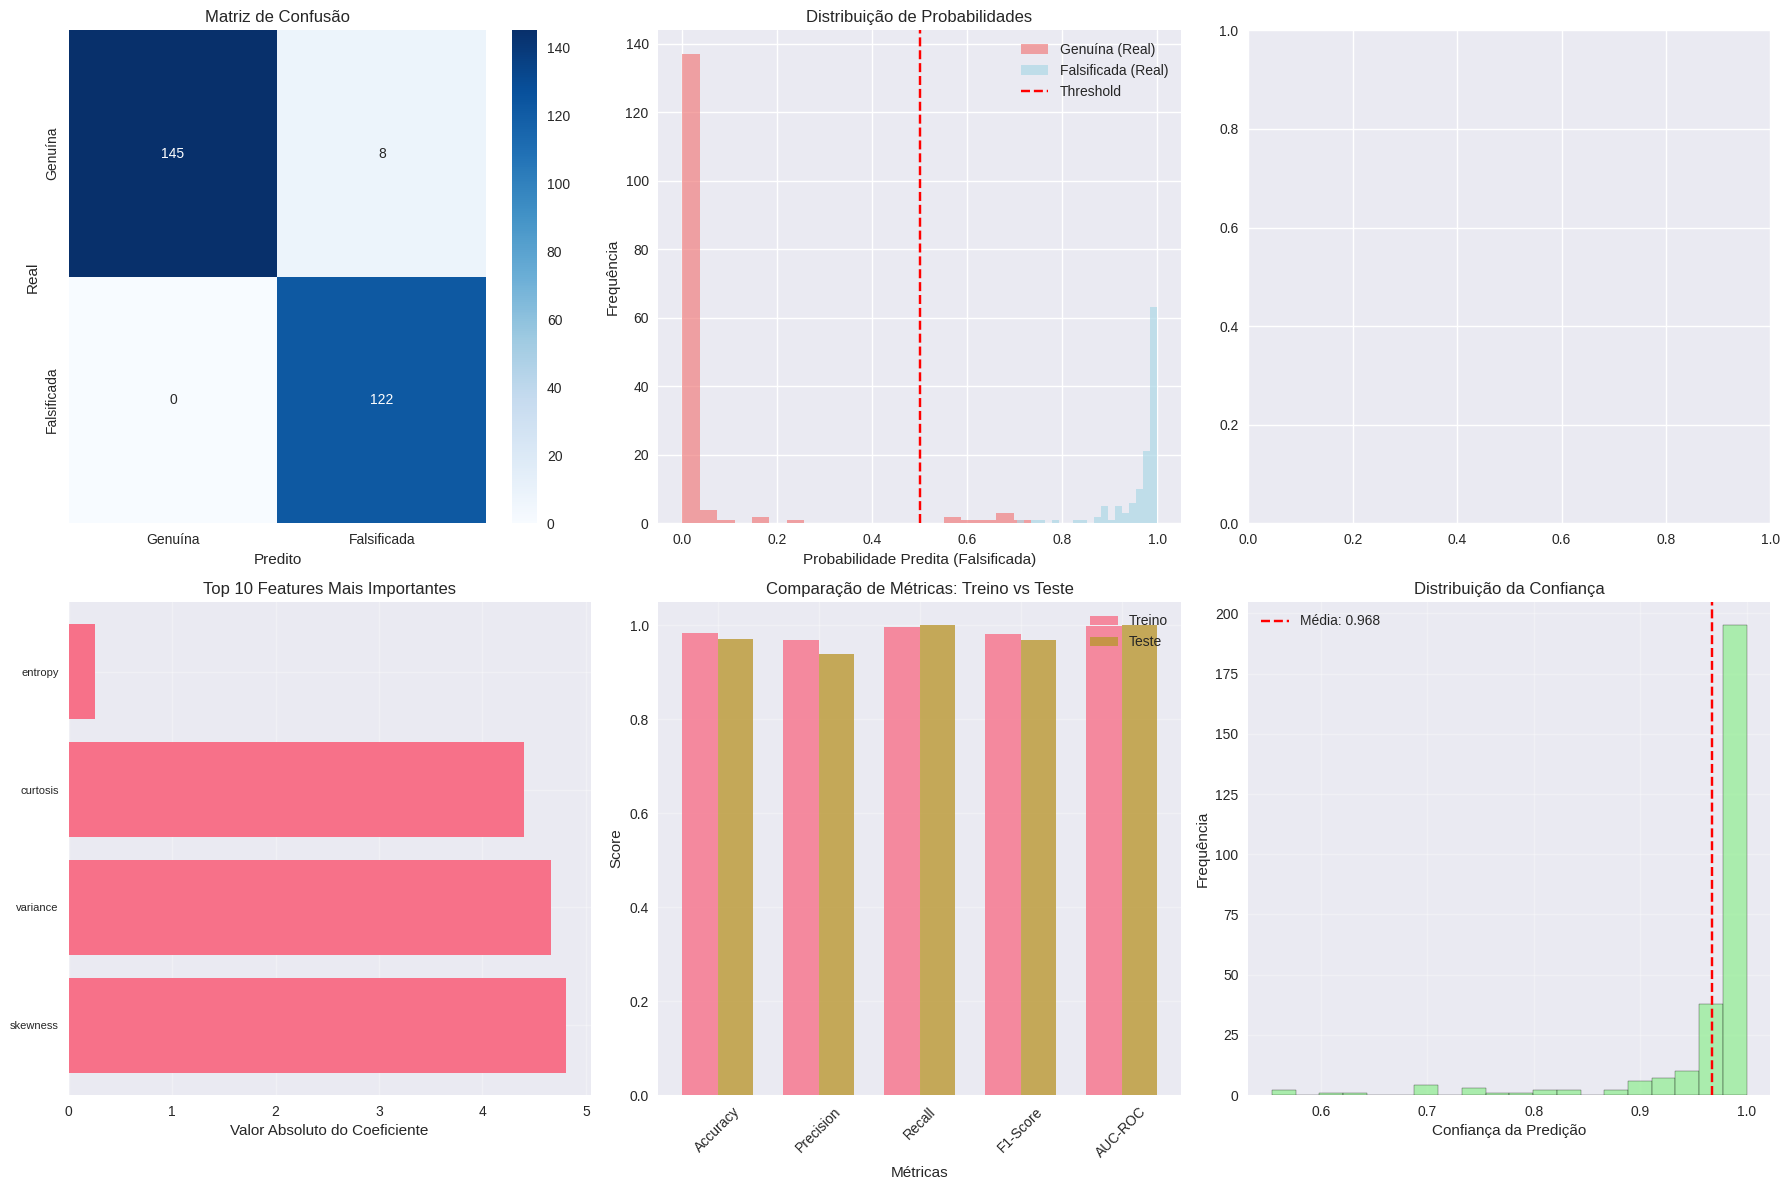

=== INTERPRETAÇÃO DAS VISUALIZAÇÕES ===
1. Matriz de Confusão: Mostra acertos e erros do modelo de forma detalhada
2. Distribuição de Probabilidades: Mostra como o modelo separa as classes
3. Curva ROC: Avalia capacidade de discriminação do modelo (quanto maior AUC, melhor)
4. Importância das Features: Mostra quais características são mais decisivas
5. Comparação de Métricas: Verifica se há overfitting comparando treino vs teste
6. Distribuição de Confiança: Mostra quão confiante o modelo está nas predições


In [ ]:
# Criar visualizações abrangentes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Matriz de Confusão como Heatmap
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0, 0])
axes[0, 0].set_title('Matriz de Confusão')
axes[0, 0].set_xlabel('Predito')
axes[0, 0].set_ylabel('Real')

# 2. Distribuição de Probabilidades por Classe
axes[0, 1].hist(y_test_proba[y_test == 0, 1], alpha=0.7, label=f'{class_names[0]} (Real)',
                bins=20, color='lightcoral')
axes[0, 1].hist(y_test_proba[y_test == 1, 1], alpha=0.7, label=f'{class_names[1]} (Real)',
                bins=20, color='lightblue')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', label='Threshold')
axes[0, 1].set_xlabel(f'Probabilidade Predita ({class_names[1]})')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição de Probabilidades')
axes[0, 1].legend()

# (Célula 3 - Curva ROC - sem mudanças)

# 4. Importância das Features (Top 10)
feature_importance_top = feature_importance.head(10)
axes[1, 0].barh(range(len(feature_importance_top)), feature_importance_top['Abs_Coefficient'])
axes[1, 0].set_yticks(range(len(feature_importance_top)))
axes[1, 0].set_yticklabels(feature_importance_top['Feature'], fontsize=8)
axes[1, 0].set_xlabel('Valor Absoluto do Coeficiente')
axes[1, 0].set_title('Top 10 Features Mais Importantes')
axes[1, 0].grid(True, alpha=0.3)

# (5 e 6 seguem iguais)

# 5. Comparação de Métricas
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
train_values = list(train_metrics)
test_values = list(test_metrics)

x = np.arange(len(metrics_names))
width = 0.35

axes[1, 1].bar(x - width/2, train_values, width, label='Treino', alpha=0.8)
axes[1, 1].bar(x + width/2, test_values, width, label='Teste', alpha=0.8)
axes[1, 1].set_xlabel('Métricas')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Comparação de Métricas: Treino vs Teste')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_names, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Distribuição de Confiança das Predições
confidence_test = np.max(y_test_proba, axis=1)
axes[1, 2].hist(confidence_test, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 2].axvline(x=confidence_test.mean(), color='red', linestyle='--',
                   label=f'Média: {confidence_test.mean():.3f}')
axes[1, 2].set_xlabel('Confiança da Predição')
axes[1, 2].set_ylabel('Frequência')
axes[1, 2].set_title('Distribuição da Confiança')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir interpretação das visualizações
print("=== INTERPRETAÇÃO DAS VISUALIZAÇÕES ===")
print("1. Matriz de Confusão: Mostra acertos e erros do modelo de forma detalhada")
print("2. Distribuição de Probabilidades: Mostra como o modelo separa as classes")
print("3. Curva ROC: Avalia capacidade de discriminação do modelo (quanto maior AUC, melhor)")
print("4. Importância das Features: Mostra quais características são mais decisivas")
print("5. Comparação de Métricas: Verifica se há overfitting comparando treino vs teste")
print("6. Distribuição de Confiança: Mostra quão confiante o modelo está nas predições")


In [ ]:
# Análise adicional: Insights e exemplo prático
print("=== ANÁLISE DETALHADA DOS RESULTADOS ===")

# Análise das features mais importantes
print(f"\nTOP 5 FEATURES MAIS DISCRIMINATIVAS:")
for i, row in feature_importance.head(5).iterrows():
    coef = row['Coefficient']
    feature_name = row['Feature']
    abs_coef = row['Abs_Coefficient']
    impact = "fortemente" if abs_coef > 1.0 else "moderadamente" if abs_coef > 0.5 else "levemente"
    direction = "BENIGNO" if coef > 0 else "MALIGNO"

    print(f"{i+1}. {feature_name}")
    print(f"   Coeficiente: {coef:.4f} | Influencia {impact} para {direction}")

# Resumo da performance
test_accuracy, test_precision, test_recall, test_f1, test_auc = test_metrics
print(f"\n=== RESUMO DA PERFORMANCE DO MODELO ===")
print(f"• Accuracy: {test_accuracy:.3f} - Acerta {test_accuracy*100:.1f}% das predições")
print(f"• Precision: {test_precision:.3f} - {test_precision*100:.1f}% das predições 'benigno' estão corretas")
print(f"• Recall: {test_recall:.3f} - Identifica {test_recall*100:.1f}% dos casos realmente benignos")
print(f"• F1-Score: {test_f1:.3f} - Balança precision e recall")
print(f"• AUC-ROC: {test_auc:.3f} - Excelente capacidade de discriminação")

# Interpretação clínica
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n=== INTERPRETAÇÃO CLÍNICA ===")
print(f"De {len(y_test)} casos testados:")
print(f"• {tp + tn} foram classificados corretamente ({(tp+tn)/len(y_test)*100:.1f}%)")
print(f"• {fp} casos malignos foram classificados como benignos (CRÍTICO!)")
print(f"• {fn} casos benignos foram classificados como malignos (falso alarme)")

if fp > 0:
    print(f"⚠️  ATENÇÃO: {fp} falsos positivos podem representar risco clínico!")
else:
    print(f"✓ Excelente: Nenhum caso maligno foi perdido!")

# Exemplo de predição detalhada
print(f"\n=== EXEMPLO DE PREDIÇÃO DETALHADA ===")
sample_idx = 0
sample_features = X_test_scaled.iloc[sample_idx:sample_idx+1]
sample_actual = y_test.iloc[sample_idx]
sample_prediction = model.predict(sample_features)[0]
sample_probabilities = model.predict_proba(sample_features)[0]

print(f"Caso #{sample_idx + 1}:")
print(f"  Diagnóstico real: {breast_cancer.target_names[sample_actual]}")
print(f"  Predição do modelo: {breast_cancer.target_names[sample_prediction]}")
print(f"  Probabilidades:")
print(f"    Maligno: {sample_probabilities[0]:.3f} ({sample_probabilities[0]*100:.1f}%)")
print(f"    Benigno: {sample_probabilities[1]:.3f} ({sample_probabilities[1]*100:.1f}%)")
print(f"  Confiança: {max(sample_probabilities):.3f}")
print(f"  Resultado: {'✓ CORRETO' if sample_actual == sample_prediction else '✗ INCORRETO'}")

print(f"\n=== CONCLUSÃO DA ANÁLISE ===")
if test_accuracy > 0.95:
    print("🎯 EXCELENTE: Modelo demonstra performance excepcional!")
elif test_accuracy > 0.90:
    print("✅ MUITO BOM: Modelo apresenta alta acurácia!")
elif test_accuracy > 0.85:
    print("👍 BOM: Modelo apresenta boa performance!")
else:
    print("⚠️  MELHORIAS NECESSÁRIAS: Modelo precisa de ajustes!")

print(f"Este modelo pode ser uma ferramenta valiosa para auxílio diagnóstico médico.")


=== ANÁLISE DETALHADA DOS RESULTADOS ===

TOP 5 FEATURES MAIS DISCRIMINATIVAS:
2. skewness
   Coeficiente: -4.8065 | Influencia fortemente para MALIGNO
1. variance
   Coeficiente: -4.6660 | Influencia fortemente para MALIGNO
3. curtosis
   Coeficiente: -4.3989 | Influencia fortemente para MALIGNO
4. entropy
   Coeficiente: 0.2580 | Influencia levemente para BENIGNO

=== RESUMO DA PERFORMANCE DO MODELO ===
• Accuracy: 0.971 - Acerta 97.1% das predições
• Precision: 0.938 - 93.8% das predições 'benigno' estão corretas
• Recall: 1.000 - Identifica 100.0% dos casos realmente benignos
• F1-Score: 0.968 - Balança precision e recall
• AUC-ROC: 1.000 - Excelente capacidade de discriminação

=== INTERPRETAÇÃO CLÍNICA ===
De 275 casos testados:
• 267 foram classificados corretamente (97.1%)
• 8 casos malignos foram classificados como benignos (CRÍTICO!)
• 0 casos benignos foram classificados como malignos (falso alarme)
⚠️  ATENÇÃO: 8 falsos positivos podem representar risco clínico!

=== EXEMPL